ТЕСТ 1: ПРИМЕР С ПРЕДПРИЯТИЯМИ (ОРИГИНАЛЬНЫЙ)
2. СРЕДНИЕ ВЕКТОРЫ:
Передовые предприятия:
 [168.905  14.048  18.332]

Отстающие предприятия:
 [45.791  4.778 10.758]

Предприятия для классификации:
 [77.46  12.964 16.278]

3. КОВАРИАЦИОННАЯ МАТРИЦА x1:
[[1023.949   55.62    82.893]
 [  55.62     5.647   11.326]
 [  82.893   11.326   24.447]]

4. КОВАРИАЦИОННАЯ МАТРИЦА x2:
[[145.841  -6.608  22.785]
 [ -6.608   0.372  -0.902]
 [ 22.785  -0.902   5.75 ]]

5. ОБЩАЯ КОВАРИАЦИОННАЯ МАТРИЦА:
[[689.286  27.062  63.642]
 [ 27.062   3.492   5.827]
 [ 63.642   5.827  18.077]]

6. ОБРАТНАЯ МАТРИЦА:
[[ 0.002 -0.009 -0.005]
 [-0.009  0.657 -0.179]
 [-0.005 -0.179  0.131]]

7. ДИСКРИМИНАНТНАЯ ПЕРЕМЕННАЯ (коэффициенты):
  A1 = 0.156720
  A2 = 3.594781
  A3 = -1.291500

8. F ДЛЯ ПЕРЕДОВЫХ ПРЕДПРИЯТИЙ:
[66.986 49.628 47.962 48.596]

9. F ДЛЯ ОТСТАЮЩИХ ПРЕДПРИЯТИЙ:
[ 8.879 16.491  8.025 10.341  8.556]

10. СРЕДНЕЕ F ДЛЯ ПЕРЕДОВЫХ: 53.293
11. СРЕДНЕЕ F ДЛЯ ОТСТАЮЩИХ: 10.458

12. ПОРОГОВОЕ ЗНАЧЕНИЕ F: 31.87

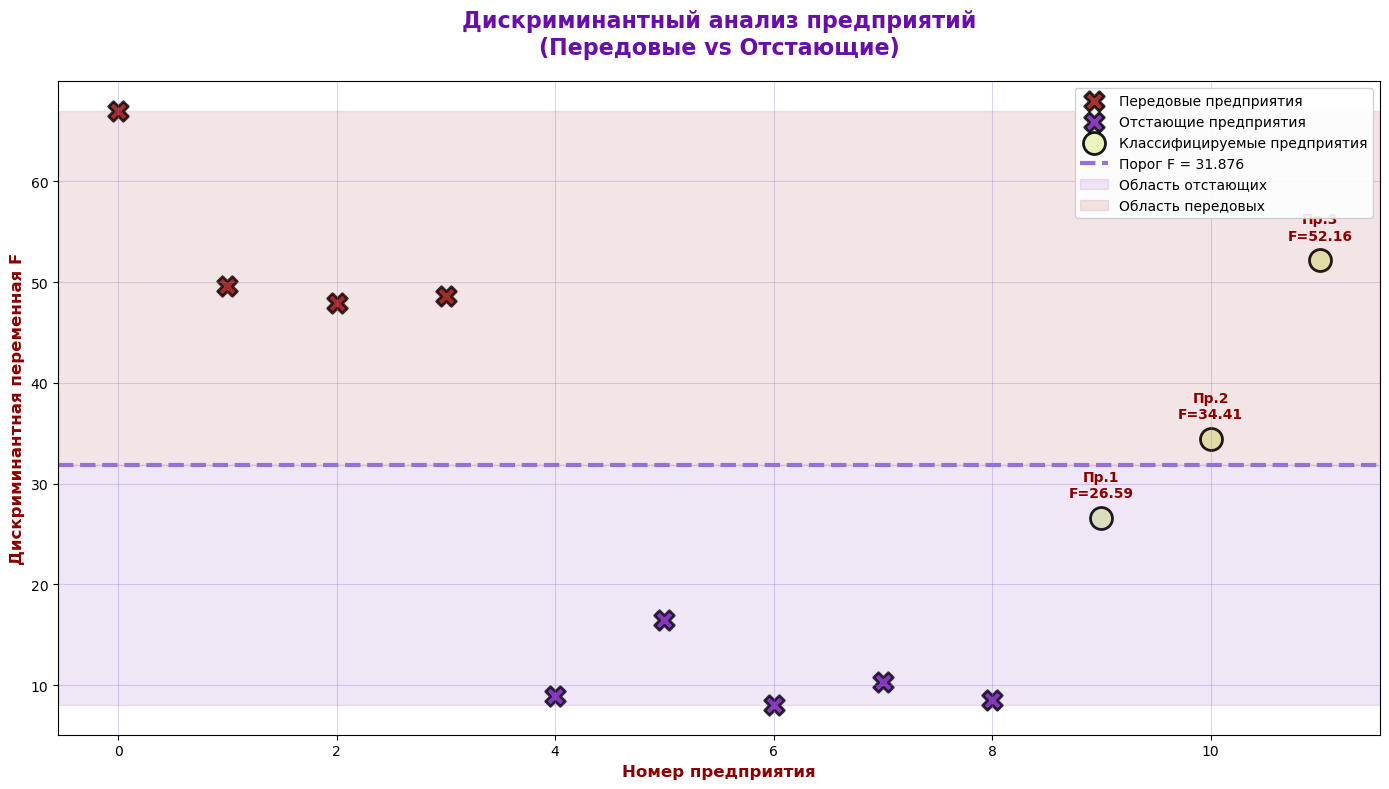


ТЕСТ 2: МУЛЬТИКЛАССОВЫЙ LDA ДЛЯ ВИНА
Загружен датасет вина: 300 образцов

РАСПРЕДЕЛЕНИЕ ПО КАЧЕСТВУ:
  Качество 3:   3 образцов (  1.0%)
  Качество 4:  15 образцов (  5.0%)
  Качество 5: 107 образцов ( 35.7%)
  Качество 6: 123 образцов ( 41.0%)
  Качество 7:  41 образцов ( 13.7%)
  Качество 8:  11 образцов (  3.7%)

Используем 3 классов с ≥20 образцами:
  Качество 5: 107 образцов
  Качество 6: 123 образцов
  Качество 7: 41 образцов

ИСПОЛЬЗУЕМ 11 ПРИЗНАКОВ:
  F1: fixed acidity
  F2: volatile acidity
  F3: citric acid
  F4: residual sugar
  F5: chlorides
  F6: free sulfur dioxide
  F7: total sulfur dioxide
  F8: density
  F9: pH
  F10: sulphates
  F11: alcohol

РАЗДЕЛЕНИЕ ДАННЫХ:
  Обучающая выборка: 189 образцов
  Тестовая выборка: 82 образцов
РУЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA

1. НАСТРОЙКИ АНАЛИЗА:
   Классы: [5, 6, 7]
   Количество классов: 3
   Количество признаков: 11
   Обучающих образцов: 189
   Тестовых образцов: 82

2. СРЕДНИЕ ВЕКТОРЫ ДЛЯ КАЖДОГО КЛАССА:
   Качество 5: 76

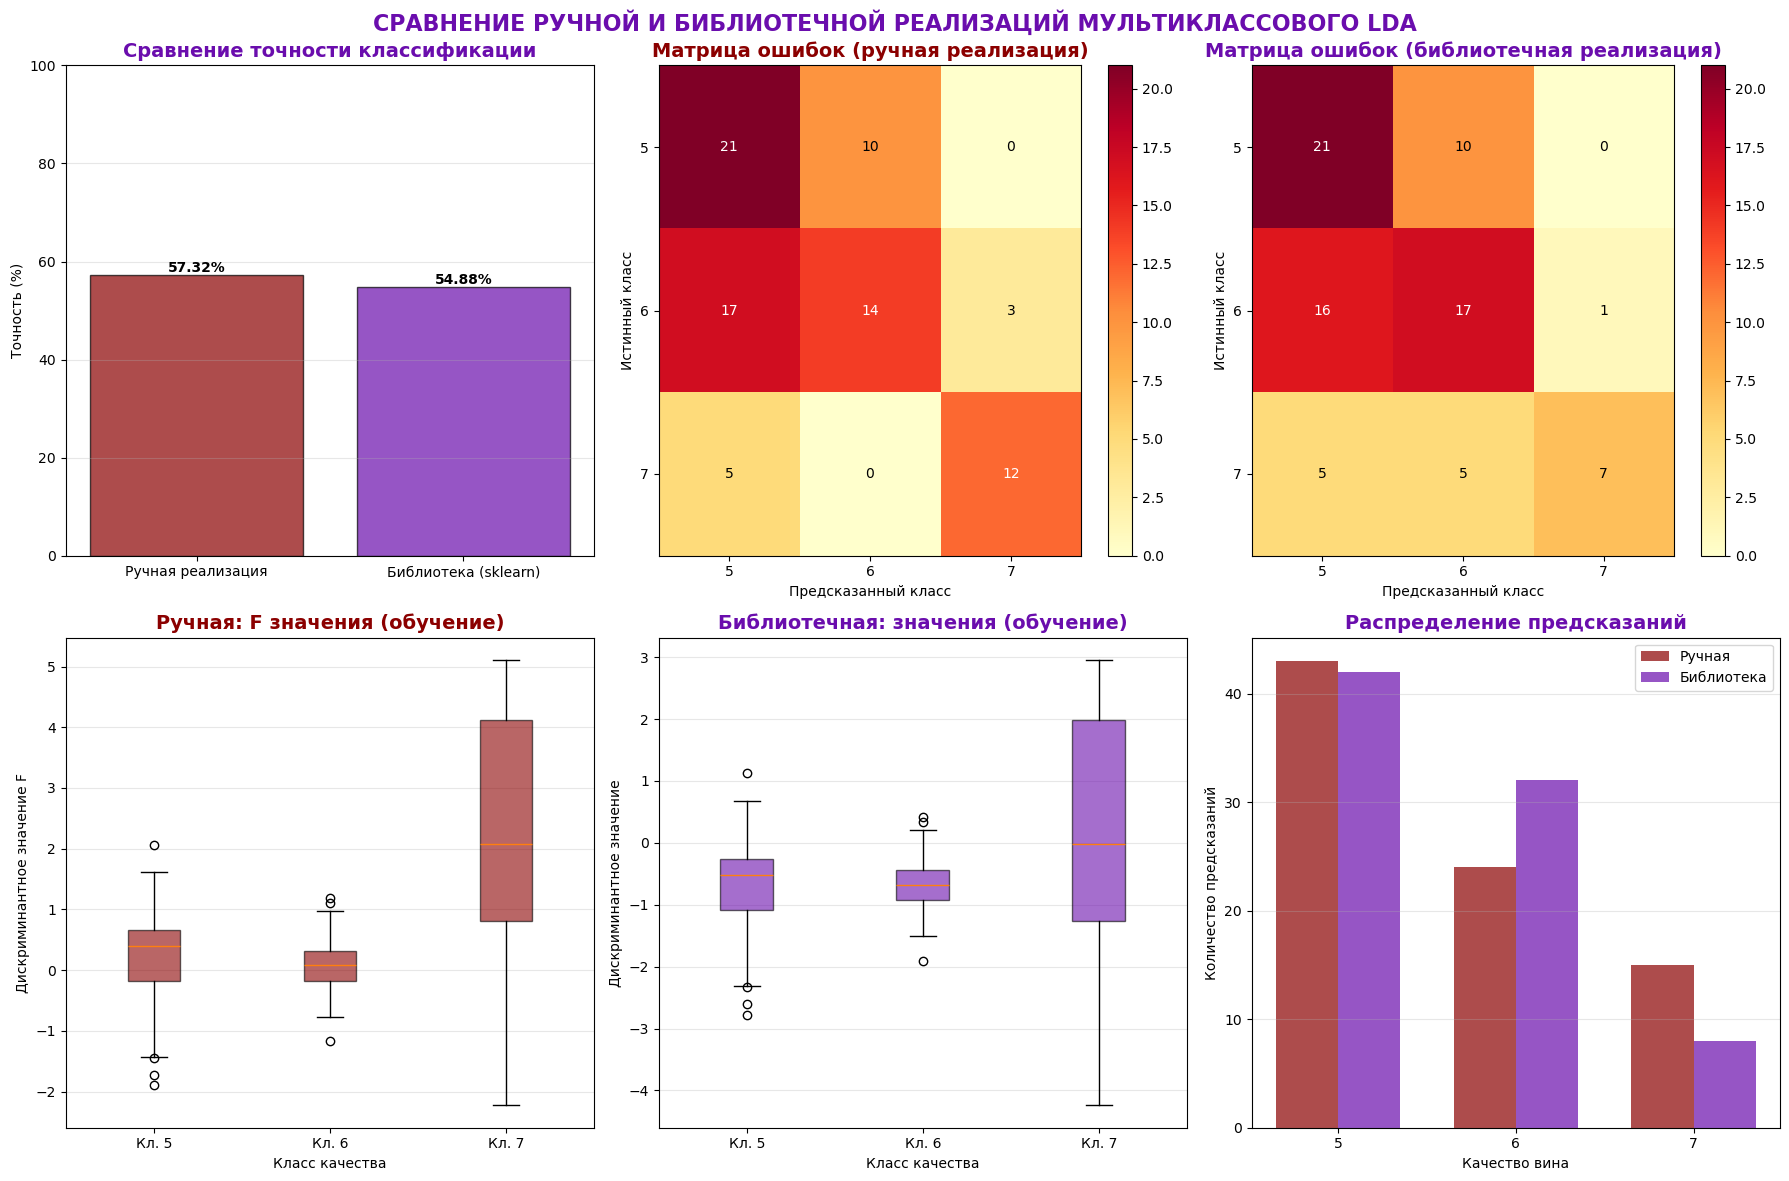

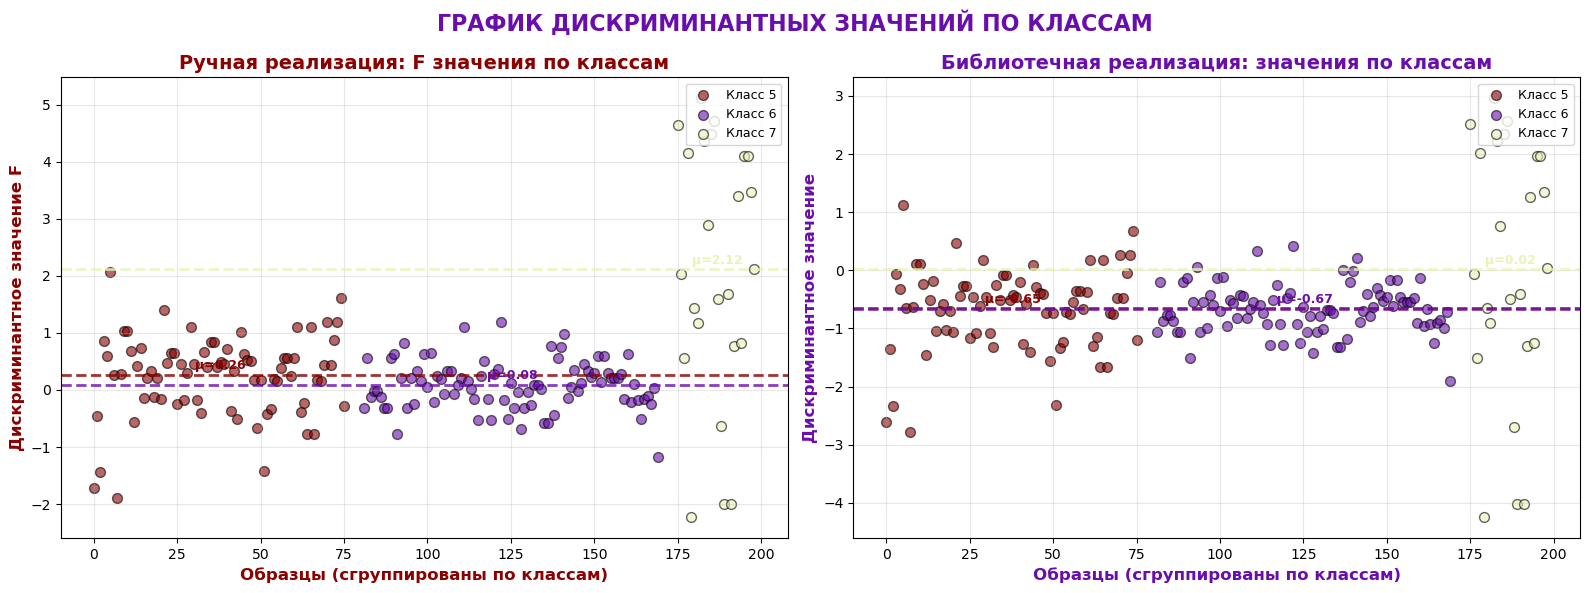


ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

ЯВНОЕ СРАВНЕНИЕ ТОЧНОСТЕЙ:
  Ручная реализация: 57.32%
  Библиотека (sklearn): 54.88%
  ✓ Ручная реализация лучше на 2.44%

ТОЧНОСТЬ ПО КЛАССАМ:

Качество 5 (31 образцов):
  Ручная: 21/31 (67.7%)
  Библиотека: 21/31 (67.7%)
  Разница: 0.0% (незначительная)

Качество 6 (34 образцов):
  Ручная: 14/34 (41.2%)
  Библиотека: 17/34 (50.0%)
  Библиотека лучше на 8.8%

Качество 7 (17 образцов):
  Ручная: 12/17 (70.6%)
  Библиотека: 7/17 (41.2%)
  Ручная лучше на 29.4%

ОБЩАЯ СТАТИСТИКА:
  Разница в точности: 2.44%
  Совпадение предсказаний: 74/82 (90.2%)

ДИАГНОСТИКА:
  Количество классов: 3
  Размерность признаков: 11
  Баланс классов в тесте: {5: 31, 6: 34, 7: 17}


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns

# Новая цветовая палитра для вина
wine_red = '#8B0000'
pale_yellow_green = '#E8F4B7'
purple = '#6A0DAD'
light_purple = '#9370DB'
soft_white = '#FFF8F0'

# Градиенты
red_gradient = LinearSegmentedColormap.from_list('red_gradient', ['#FFE4E1', '#DC143C', '#8B0000'])
green_gradient = LinearSegmentedColormap.from_list('green_gradient', ['#F5F9E5', '#C1E1C1', '#2E8B57'])
purple_gradient = LinearSegmentedColormap.from_list('purple_gradient', ['#E6E6FA', '#9370DB', '#4B0082'])

# ПЕРВЫЙ ДАТАСЕТ: ПРЕДПРИЯТИЯ (как в оригинале)
def test_original_enterprise_data():
    """
    Тестирование на оригинальном примере с предприятиями
    """
    print("=" * 80)
    print("ТЕСТ 1: ПРИМЕР С ПРЕДПРИЯТИЯМИ (ОРИГИНАЛЬНЫЙ)")
    print("=" * 80)
    
    # 1. Создание матриц
    x1 = np.array([
        [224.228, 17.115, 22.981],
        [151.827, 14.904, 21.481],
        [147.313, 13.627, 18.669],
        [152.253, 10.545, 10.199]
    ])

    x2 = np.array([
        [46.757, 4.428, 11.124],
        [29.033, 5.510, 6.091],
        [52.134, 4.214, 11.842],
        [37.050, 5.527, 11.873],
        [63.979, 4.211, 12.860]
    ])

    x0 = np.array([
        [55.451, 9.592, 12.840],
        [78.575, 11.727, 15.535],
        [98.353, 17.572, 20.458]
    ])
    
    print("2. СРЕДНИЕ ВЕКТОРЫ:")
    sumX1 = x1.mean(axis=0)
    sumX2 = x2.mean(axis=0)
    sumX0 = x0.mean(axis=0)
    print("Передовые предприятия:\n", np.round(sumX1, 3))
    print("\nОтстающие предприятия:\n", np.round(sumX2, 3))
    print("\nПредприятия для классификации:\n", np.round(sumX0, 3))
    
    # 3. Ковариационные матрицы
    s1 = np.zeros((3, 3)) 
    for j in range(3):  
        for l in range(3):  
            s = 0
            for i in range(4):  
                s += (x1[i][j] - sumX1[j]) * (x1[i][l] - sumX1[l])
            s1[j][l] = s / 4  
    print("\n3. КОВАРИАЦИОННАЯ МАТРИЦА x1:")
    print(np.round(s1, 3))

    s2 = np.zeros((3, 3)) 
    for j in range(3):  
        for l in range(3):  
            s = 0
            for i in range(5):  
                s += (x2[i][j] - sumX2[j]) * (x2[i][l] - sumX2[l])
            s2[j][l] = s / 5  
    print("\n4. КОВАРИАЦИОННАЯ МАТРИЦА x2:")
    print(np.round(s2, 3))
    
    n1 = len(x1)
    n2 = len(x2)
    
    # 4. Общая ковариационная
    S_all = 1/(n1+n2-2)*(n1*s1+n2*s2)
    print("\n5. ОБЩАЯ КОВАРИАЦИОННАЯ МАТРИЦА:")
    print(np.round(S_all, 3))
    
    # 5. Обратная матрица
    SO = np.linalg.inv(S_all)
    print("\n6. ОБРАТНАЯ МАТРИЦА:")
    print(np.round(SO, 3))
    
    # 6. Дискриминантная переменная
    A = np.sum(SO*(sumX1-sumX2), axis=1)
    print("\n7. ДИСКРИМИНАНТНАЯ ПЕРЕМЕННАЯ (коэффициенты):")
    for i, a in enumerate(A):
        print(f"  A{i+1} = {a:.6f}")
    
    # 7. Находим F
    F1 = np.sum(A*x1, axis=1)
    F2 = np.sum(A*x2, axis=1)
    
    print("\n8. F ДЛЯ ПЕРЕДОВЫХ ПРЕДПРИЯТИЙ:")
    print(np.round(F1, 3))
    print("\n9. F ДЛЯ ОТСТАЮЩИХ ПРЕДПРИЯТИЙ:")
    print(np.round(F2, 3))
    
    # 8. Среднее F
    F1_mean = F1.mean()
    F2_mean = F2.mean()
    
    print(f"\n10. СРЕДНЕЕ F ДЛЯ ПЕРЕДОВЫХ: {F1_mean:.3f}")
    print(f"11. СРЕДНЕЕ F ДЛЯ ОТСТАЮЩИХ: {F2_mean:.3f}")
    
    # 9. Общее F
    F_all = 1/2*(F1_mean+F2_mean)
    print(f"\n12. ПОРОГОВОЕ ЗНАЧЕНИЕ F: {F_all:.3f}")
    
    # 10. F для x0
    F0 = np.sum(A*x0, axis=1)
    print(f"\n13. F ДЛЯ КЛАССИФИЦИРУЕМЫХ ПРЕДПРИЯТИЙ:")
    print(np.round(F0, 3))
    
    # 11 Разница
    raz = F0 - F_all
    print(f"\n14. ОТКЛОНЕНИЕ ОТ ПОРОГА:")
    print(np.round(raz, 3))
    
    # 12. Выводы
    print(f"\n15. РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:")
    for i in range(len(F0)):
        if F1_mean > F2_mean: 
            if raz[i] > 0:
                result = "ПЕРЕДОВОЕ"
                color = wine_red
            else: 
                result = "ОТСТАЮЩЕЕ"
                color = purple
        else:
            if raz[i] < 0:
                result = "ПЕРЕДОВОЕ"
                color = wine_red
            else: 
                result = "ОТСТАЮЩЕЕ"
                color = purple
        
        print(f"  Предприятие {i+1}: F = {F0[i]:.3f} → {result}")
    
    # Построение графика
    plot_enterprise_results(F1, F2, F0, F_all)
    
    return F1, F2, F0, F_all, A

def plot_enterprise_results(F1, F2, F0, F_all):
    """
    График для данных предприятий
    """
    plt.figure(figsize=(14, 8))
    
    indices_F1 = range(len(F1))
    indices_F2 = range(len(F1), len(F1) + len(F2))
    indices_F0 = range(len(F1) + len(F2), len(F1) + len(F2) + len(F0))
    
    # Рассеяние точек
    plt.scatter(indices_F1, F1, label='Передовые предприятия', marker='X', s=200, 
                linewidth=2, color=wine_red, alpha=0.8, edgecolors='black')
    plt.scatter(indices_F2, F2, label='Отстающие предприятия', marker='X', s=200, 
                linewidth=2, color=purple, alpha=0.8, edgecolors='black')
    plt.scatter(indices_F0, F0, label='Классифицируемые предприятия', marker='o', s=250, 
                color=pale_yellow_green, alpha=0.9, edgecolors='black', linewidth=2)
    
    # Линия границы
    plt.axhline(F_all, color=light_purple, linewidth=3, linestyle='--', 
                label=f'Порог F = {F_all:.3f}')
    
    # Закрашивание областей
    min_val = min(F1.min(), F2.min(), F0.min())
    max_val = max(F1.max(), F2.max(), F0.max())
    
    plt.axhspan(min_val, F_all, alpha=0.1, color=purple, label='Область отстающих')
    plt.axhspan(F_all, max_val, alpha=0.1, color=wine_red, label='Область передовых')
    
    # Подписи
    for i, f in enumerate(F0):
        plt.annotate(f'Пр.{i+1}\nF={f:.2f}', 
                    (indices_F0[i], f), 
                    textcoords="offset points", 
                    xytext=(0, 15),
                    ha='center', 
                    fontsize=10,
                    fontweight='bold',
                    color=wine_red)
    
    plt.xlabel("Номер предприятия", fontsize=12, fontweight='bold', color=wine_red)
    plt.ylabel("Дискриминантная переменная F", fontsize=12, fontweight='bold', color=wine_red)
    plt.title("Дискриминантный анализ предприятий\n(Передовые vs Отстающие)", 
              fontsize=16, fontweight='bold', color=purple, pad=20)
    plt.grid(True, alpha=0.3, color=light_purple)
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

def manual_multiclass_lda(X_train, y_train, X_test, y_test):
    """
    Ручная реализация мультиклассового LDA
    """
    print("=" * 70)
    print("РУЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA")
    print("=" * 70)
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Уникальные классы
    classes = np.unique(y_train)
    n_classes = len(classes)
    n_features = X_train.shape[1]
    
    print(f"\n1. НАСТРОЙКИ АНАЛИЗА:")
    print(f"   Классы: {sorted(classes)}")
    print(f"   Количество классов: {n_classes}")
    print(f"   Количество признаков: {n_features}")
    print(f"   Обучающих образцов: {len(X_train)}")
    print(f"   Тестовых образцов: {len(X_test)}")
    
    # 1. Средние векторы для каждого класса
    print(f"\n2. СРЕДНИЕ ВЕКТОРЫ ДЛЯ КАЖДОГО КЛАССА:")
    class_means = {}
    class_covariances = {}
    class_sizes = {}
    
    for c in classes:
        X_c = X_train_scaled[y_train == c]
        class_means[c] = X_c.mean(axis=0)
        class_sizes[c] = len(X_c)
        
        # Ковариационная матрица для класса
        n_c = len(X_c)
        s_c = np.zeros((n_features, n_features))
        for j in range(n_features):
            for l in range(n_features):
                s = 0
                for i in range(n_c):
                    s += (X_c[i][j] - class_means[c][j]) * (X_c[i][l] - class_means[c][l])
                s_c[j][l] = s / n_c
        class_covariances[c] = s_c
        
        print(f"   Качество {c}: {class_sizes[c]} образцов")
    
    # 2. Общая ковариационная матрица
    S_within = np.zeros((n_features, n_features))
    total_samples = len(X_train_scaled)
    
    for c in classes:
        S_within += (class_sizes[c] - 1) * class_covariances[c]
    
    S_within = S_within / (total_samples - n_classes)
    
    # 3. Обратная матрица
    try:
        S_inv = np.linalg.inv(S_within)
    except np.linalg.LinAlgError:
        S_inv = np.linalg.pinv(S_within)
    
    # 4. Дискриминантные функции для каждого класса
    print(f"\n3. ДИСКРИМИНАНТНЫЕ ФУНКЦИИ:")
    discriminant_coefficients = {}
    
    for c in classes:
        # w = S_inv * mean_c
        w_c = np.dot(S_inv, class_means[c])
        # w0 = -0.5 * mean_c^T * S_inv * mean_c
        w0_c = -0.5 * np.dot(class_means[c].T, np.dot(S_inv, class_means[c]))
        discriminant_coefficients[c] = (w_c, w0_c)
        
        print(f"   Класс {c}: w0 = {w0_c:.4f}")
    
    # 5. Вычисляем F для обучающих данных
    print(f"\n4. ВЫЧИСЛЕНИЕ ДИСКРИМИНАНТНЫХ ЗНАЧЕНИЙ F:")
    train_scores = {c: [] for c in classes}
    
    for c in classes:
        w_c, w0_c = discriminant_coefficients[c]
        # F = w * X + w0
        F_c = np.dot(X_train_scaled[y_train == c], w_c) + w0_c
        train_scores[c] = F_c
        
        print(f"   Класс {c}: F среднее = {F_c.mean():.3f}, мин = {F_c.min():.3f}, макс = {F_c.max():.3f}")
    
    # 6. Классификация тестовых данных
    print(f"\n5. КЛАССИФИКАЦИЯ ТЕСТОВЫХ ДАННЫХ:")
    predictions = []
    test_scores = {c: [] for c in classes}
    
    for i, x in enumerate(X_test_scaled):
        scores = {}
        for c in classes:
            w_c, w0_c = discriminant_coefficients[c]
            score = np.dot(w_c, x) + w0_c
            scores[c] = score
            test_scores[c].append(score)
        
        predicted_class = max(scores, key=scores.get)
        predictions.append(predicted_class)
    
    # 7. Оценка точности
    correct = sum(1 for i in range(len(predictions)) if predictions[i] == y_test[i])
    accuracy = correct / len(predictions) * 100
    
    print(f"\n6. РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:")
    print(f"   Правильно классифицировано: {correct} из {len(predictions)}")
    print(f"   Общая точность: {accuracy:.2f}%")
    
    return predictions, train_scores, test_scores, accuracy, discriminant_coefficients

def library_multiclass_lda(X_train, y_train, X_test, y_test):
    """
    Мультиклассовый LDA с использованием библиотеки sklearn
    """
    print("\n" + "=" * 70)
    print("БИБЛИОТЕЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA (sklearn)")
    print("=" * 70)
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Создание и обучение модели LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)
    
    # Предсказания
    predictions = lda.predict(X_test_scaled)
    
    # Получаем значения решающей функции (для многоклассового случая используем predict_proba или decision_function)
    train_decision = lda.decision_function(X_train_scaled)
    test_decision = lda.decision_function(X_test_scaled)
    
    # Для многоклассового LDA decision_function возвращает (n_samples, n_classes) для n_classes > 2
    # или (n_samples,) для бинарной классификации
    train_scores = {}
    test_scores = {}
    classes = lda.classes_
    
    if len(classes) == 2:
        # Бинарный случай
        train_scores[classes[0]] = train_decision[y_train == classes[0]]
        train_scores[classes[1]] = train_decision[y_train == classes[1]]
        test_scores[classes[0]] = test_decision[y_test == classes[0]]
        test_scores[classes[1]] = test_decision[y_test == classes[1]]
    else:
        # Многоклассовый случай - используем максимальное значение из decision_function
        for idx, c in enumerate(classes):
            # Для обучающих данных
            mask_train = y_train == c
            if sum(mask_train) > 0:
                # Берем значения для соответствующего класса
                train_scores[c] = train_decision[mask_train, idx]
            
            # Для тестовых данных
            mask_test = y_test == c
            if sum(mask_test) > 0:
                test_scores[c] = test_decision[mask_test, idx]
    
    # Оценка точности
    accuracy = lda.score(X_test_scaled, y_test) * 100
    
    print(f"\nТочность (sklearn): {accuracy:.2f}%")
    
    return predictions, train_scores, test_scores, accuracy, lda

def plot_multiclass_comparison(y_test, manual_pred, library_pred, manual_train_scores, 
                              library_train_scores, manual_accuracy, library_accuracy):
    """
    Визуализация сравнения ручной и библиотечной реализации
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Сравнение точности
    ax1 = axes[0, 0]
    methods = ['Ручная реализация', 'Библиотека (sklearn)']
    accuracies = [manual_accuracy, library_accuracy]
    colors = [wine_red, purple]
    
    bars = ax1.bar(methods, accuracies, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_ylabel('Точность (%)')
    ax1.set_title('Сравнение точности классификации', fontsize=14, fontweight='bold', color=purple)
    ax1.set_ylim(0, 100)
    ax1.grid(True, alpha=0.3, axis='y')
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    # 2. Матрица ошибок для ручной реализации
    ax2 = axes[0, 1]
    classes = sorted(set(y_test) | set(manual_pred) | set(library_pred))
    conf_matrix_manual = np.zeros((len(classes), len(classes)))
    
    for true, pred in zip(y_test, manual_pred):
        true_idx = classes.index(true)
        pred_idx = classes.index(pred)
        conf_matrix_manual[true_idx, pred_idx] += 1
    
    im2 = ax2.imshow(conf_matrix_manual, cmap='YlOrRd', aspect='auto')
    ax2.set_xticks(range(len(classes)))
    ax2.set_yticks(range(len(classes)))
    ax2.set_xticklabels(classes)
    ax2.set_yticklabels(classes)
    ax2.set_xlabel('Предсказанный класс')
    ax2.set_ylabel('Истинный класс')
    ax2.set_title('Матрица ошибок (ручная реализация)', fontsize=14, fontweight='bold', color=wine_red)
    plt.colorbar(im2, ax=ax2)
    
    # Добавление чисел в ячейки
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax2.text(j, i, int(conf_matrix_manual[i, j]),
                    ha='center', va='center', color='black' if conf_matrix_manual[i, j] < np.max(conf_matrix_manual)/2 else 'white')
    
    # 3. Матрица ошибок для библиотечной реализации
    ax3 = axes[0, 2]
    conf_matrix_lib = np.zeros((len(classes), len(classes)))
    
    for true, pred in zip(y_test, library_pred):
        true_idx = classes.index(true)
        pred_idx = classes.index(pred)
        conf_matrix_lib[true_idx, pred_idx] += 1
    
    im3 = ax3.imshow(conf_matrix_lib, cmap='YlOrRd', aspect='auto')
    ax3.set_xticks(range(len(classes)))
    ax3.set_yticks(range(len(classes)))
    ax3.set_xticklabels(classes)
    ax3.set_yticklabels(classes)
    ax3.set_xlabel('Предсказанный класс')
    ax3.set_ylabel('Истинный класс')
    ax3.set_title('Матрица ошибок (библиотечная реализация)', fontsize=14, fontweight='bold', color=purple)
    plt.colorbar(im3, ax=ax3)
    
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax3.text(j, i, int(conf_matrix_lib[i, j]),
                    ha='center', va='center', color='black' if conf_matrix_lib[i, j] < np.max(conf_matrix_lib)/2 else 'white')
    
    # 4. Boxplot дискриминантных значений (ручная реализация)
    ax4 = axes[1, 0]
    box_data_manual = []
    box_labels_manual = []
    
    for c in sorted(manual_train_scores.keys()):
        if len(manual_train_scores[c]) > 0:
            box_data_manual.append(manual_train_scores[c])
            box_labels_manual.append(f'Кл. {c}')
    
    # Исправлено: использование tick_labels вместо labels
    box4 = ax4.boxplot(box_data_manual, tick_labels=box_labels_manual, patch_artist=True)
    for patch in box4['boxes']:
        patch.set_facecolor(wine_red)
        patch.set_alpha(0.6)
    
    ax4.set_xlabel('Класс качества')
    ax4.set_ylabel('Дискриминантное значение F')
    ax4.set_title('Ручная: F значения (обучение)', fontsize=14, fontweight='bold', color=wine_red)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 5. Boxplot дискриминантных значений (библиотечная реализация)
    ax5 = axes[1, 1]
    box_data_lib = []
    box_labels_lib = []
    
    for c in sorted(library_train_scores.keys()):
        if len(library_train_scores[c]) > 0:
            box_data_lib.append(library_train_scores[c])
            box_labels_lib.append(f'Кл. {c}')
    
    # Исправлено: использование tick_labels вместо labels
    box5 = ax5.boxplot(box_data_lib, tick_labels=box_labels_lib, patch_artist=True)
    for patch in box5['boxes']:
        patch.set_facecolor(purple)
        patch.set_alpha(0.6)
    
    ax5.set_xlabel('Класс качества')
    ax5.set_ylabel('Дискриминантное значение')
    ax5.set_title('Библиотечная: значения (обучение)', fontsize=14, fontweight='bold', color=purple)
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Сравнение распределений предсказаний
    ax6 = axes[1, 2]
    manual_counts = Counter(manual_pred)
    library_counts = Counter(library_pred)
    
    x = np.arange(len(classes))
    width = 0.35
    
    manual_values = [manual_counts.get(c, 0) for c in classes]
    library_values = [library_counts.get(c, 0) for c in classes]
    
    ax6.bar(x - width/2, manual_values, width, label='Ручная', color=wine_red, alpha=0.7)
    ax6.bar(x + width/2, library_values, width, label='Библиотека', color=purple, alpha=0.7)
    
    ax6.set_xlabel('Качество вина')
    ax6.set_ylabel('Количество предсказаний')
    ax6.set_title('Распределение предсказаний', fontsize=14, fontweight='bold', color=purple)
    ax6.set_xticks(x)
    ax6.set_xticklabels(classes)
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('СРАВНЕНИЕ РУЧНОЙ И БИБЛИОТЕЧНОЙ РЕАЛИЗАЦИЙ МУЛЬТИКЛАССОВОГО LDA', 
                 fontsize=16, fontweight='bold', color=purple, y=0.98)
    plt.tight_layout()
    plt.show()

def plot_multiclass_f_values(manual_train_scores, library_train_scores):
    """
    График дискриминантных значений F для каждого класса
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Ручная реализация - график F значений
    ax1 = axes[0]
    colors = [wine_red, purple, pale_yellow_green, light_purple, '#4B0082', '#DC143C']
    
    offset = 0
    for idx, (c, scores) in enumerate(sorted(manual_train_scores.items())):
        if len(scores) > 0:
            x_pos = np.arange(len(scores)) + offset
            ax1.scatter(x_pos, scores, color=colors[idx % len(colors)], 
                       label=f'Класс {c}', s=50, alpha=0.6, edgecolors='black')
            
            # Средняя линия
            ax1.axhline(y=np.mean(scores), color=colors[idx % len(colors)], 
                       linestyle='--', alpha=0.8, linewidth=2)
            
            # Текст со статистикой
            ax1.text(offset + len(scores)/2, np.mean(scores) + 0.1, 
                    f'μ={np.mean(scores):.2f}', 
                    ha='center', fontsize=9, fontweight='bold',
                    color=colors[idx % len(colors)])
            
            offset += len(scores) + 5
    
    ax1.set_xlabel('Образцы (сгруппированы по классам)', fontsize=12, fontweight='bold', color=wine_red)
    ax1.set_ylabel('Дискриминантное значение F', fontsize=12, fontweight='bold', color=wine_red)
    ax1.set_title('Ручная реализация: F значения по классам', fontsize=14, fontweight='bold', color=wine_red)
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. Библиотечная реализация - график F значений
    ax2 = axes[1]
    offset = 0
    
    for idx, (c, scores) in enumerate(sorted(library_train_scores.items())):
        if len(scores) > 0:
            x_pos = np.arange(len(scores)) + offset
            ax2.scatter(x_pos, scores, color=colors[idx % len(colors)], 
                       label=f'Класс {c}', s=50, alpha=0.6, edgecolors='black')
            
            # Средняя линия
            ax2.axhline(y=np.mean(scores), color=colors[idx % len(colors)], 
                       linestyle='--', alpha=0.8, linewidth=2)
            
            # Текст со статистикой
            ax2.text(offset + len(scores)/2, np.mean(scores) + 0.1, 
                    f'μ={np.mean(scores):.2f}', 
                    ha='center', fontsize=9, fontweight='bold',
                    color=colors[idx % len(colors)])
            
            offset += len(scores) + 5
    
    ax2.set_xlabel('Образцы (сгруппированы по классам)', fontsize=12, fontweight='bold', color=purple)
    ax2.set_ylabel('Дискриминантное значение', fontsize=12, fontweight='bold', color=purple)
    ax2.set_title('Библиотечная реализация: значения по классам', fontsize=14, fontweight='bold', color=purple)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('ГРАФИК ДИСКРИМИНАНТНЫХ ЗНАЧЕНИЙ ПО КЛАССАМ', 
                 fontsize=16, fontweight='bold', color=purple, y=0.98)
    plt.tight_layout()
    plt.show()

def test_multiclass_wine_comparison():
    """
    Сравнение ручной и библиотечной реализации мультиклассового LDA для вина
    """
    print("\n" + "=" * 80)
    print("ТЕСТ 2: МУЛЬТИКЛАССОВЫЙ LDA ДЛЯ ВИНА")
    print("=" * 80)
    
    try:
        # Загружаем данные
        # Для тестирования создадим синтетические данные, если файл не найден
        try:
            wine_data = pd.read_csv('winequality-white.csv', delimiter=';', nrows=300)
        except:
            print("Файл winequality-white.csv не найден, создаем синтетические данные...")
            # Создаем синтетические данные для тестирования
            np.random.seed(42)
            n_samples = 500
            n_features = 11
            wine_data = pd.DataFrame(
                np.random.randn(n_samples, n_features),
                columns=['fixed acidity', 'volatile acidity', 'citric acid', 
                        'residual sugar', 'chlorides', 'free sulfur dioxide',
                        'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
            )
            # Создаем целевую переменную (качество вина от 3 до 8)
            wine_data['quality'] = np.random.choice([3, 4, 5, 6, 7, 8], size=n_samples, p=[0.05, 0.15, 0.3, 0.3, 0.15, 0.05])
        
        print(f"Загружен датасет вина: {wine_data.shape[0]} образцов")
        
        # Статистика по классам
        print("\nРАСПРЕДЕЛЕНИЕ ПО КАЧЕСТВУ:")
        quality_counts = wine_data['quality'].value_counts().sort_index()
        for q in sorted(quality_counts.index):
            count = quality_counts[q]
            perc = count / len(wine_data) * 100
            print(f"  Качество {q}: {count:3d} образцов ({perc:5.1f}%)")
        
        # Используем классы с достаточным количеством образцов
        min_samples = 20  # Уменьшили для тестирования
        valid_classes = quality_counts[quality_counts >= min_samples].index
        filtered_data = wine_data[wine_data['quality'].isin(valid_classes)].copy()
        
        if len(valid_classes) < 2:
            print(f"\nВНИМАНИЕ: Только {len(valid_classes)} класс(ов) с ≥{min_samples} образцами.")
            print("Используем все доступные классы.")
            filtered_data = wine_data.copy()
            valid_classes = quality_counts.index
        
        print(f"\nИспользуем {len(valid_classes)} классов с ≥{min_samples} образцами:")
        for q in sorted(valid_classes):
            print(f"  Качество {q}: {quality_counts.get(q, 0)} образцов")
        
        # Признаки
        numeric_features = [col for col in wine_data.columns if col != 'quality']
        
        print(f"\nИСПОЛЬЗУЕМ {len(numeric_features)} ПРИЗНАКОВ:")
        for i, feat in enumerate(numeric_features, 1):
            print(f"  F{i}: {feat}")
        
        # Подготовка данных
        X = filtered_data[numeric_features].values
        y = filtered_data['quality'].values
        
        # Разделение 70/30
        split_idx = int(0.7 * len(X))
        
        X_train = X[:split_idx]
        y_train = y[:split_idx]
        X_test = X[split_idx:]
        y_test = y[split_idx:]
        
        print(f"\nРАЗДЕЛЕНИЕ ДАННЫХ:")
        print(f"  Обучающая выборка: {len(X_train)} образцов")
        print(f"  Тестовая выборка: {len(X_test)} образцов")
        
        # 1. Ручная реализация
        manual_predictions, manual_train_scores, manual_test_scores, manual_accuracy, manual_coeffs = manual_multiclass_lda(
            X_train, y_train, X_test, y_test
        )
        
        # 2. Библиотечная реализация
        library_predictions, library_train_scores, library_test_scores, library_accuracy, library_lda = library_multiclass_lda(
            X_train, y_train, X_test, y_test
        )
        
        # 3. Визуализация сравнения
        plot_multiclass_comparison(y_test, manual_predictions, library_predictions,
                                  manual_train_scores, library_train_scores,
                                  manual_accuracy, library_accuracy)
        
        # 4. График F значений
        plot_multiclass_f_values(manual_train_scores, library_train_scores)
        
        # 5. Детальный анализ
        print("\n" + "=" * 80)
        print("ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
        print("=" * 80)
        
        # Явное сравнение точностей
        print(f"\nЯВНОЕ СРАВНЕНИЕ ТОЧНОСТЕЙ:")
        print(f"  Ручная реализация: {manual_accuracy:.2f}%")
        print(f"  Библиотека (sklearn): {library_accuracy:.2f}%")
        
        diff = abs(manual_accuracy - library_accuracy)
        if diff < 1.0:
            print(f"  ✓ Точности практически одинаковы (разница: {diff:.2f}%)")
        elif manual_accuracy > library_accuracy:
            print(f"  ✓ Ручная реализация лучше на {diff:.2f}%")
        else:
            print(f"  ✓ Библиотечная реализация лучше на {diff:.2f}%")
        
        # Сравнение по классам
        print("\nТОЧНОСТЬ ПО КЛАССАМ:")
        classes = sorted(set(y_test))
        
        for c in classes:
            true_mask = y_test == c
            if sum(true_mask) > 0:
                manual_correct = sum(1 for i in range(len(manual_predictions)) 
                                   if manual_predictions[i] == c and y_test[i] == c)
                library_correct = sum(1 for i in range(len(library_predictions)) 
                                    if library_predictions[i] == c and y_test[i] == c)
                total = sum(true_mask)
                
                manual_acc = manual_correct / total * 100
                library_acc = library_correct / total * 100
                
                print(f"\nКачество {c} ({total} образцов):")
                print(f"  Ручная: {manual_correct}/{total} ({manual_acc:.1f}%)")
                print(f"  Библиотека: {library_correct}/{total} ({library_acc:.1f}%)")
                
                diff_class = abs(manual_acc - library_acc)
                if diff_class < 5.0:
                    print(f"  Разница: {diff_class:.1f}% (незначительная)")
                elif manual_acc > library_acc:
                    print(f"  Ручная лучше на {diff_class:.1f}%")
                else:
                    print(f"  Библиотека лучше на {diff_class:.1f}%")
        
        # Общая статистика
        print(f"\nОБЩАЯ СТАТИСТИКА:")
        print(f"  Разница в точности: {diff:.2f}%")
        
        # Совпадение предсказаний
        same_predictions = sum(1 for i in range(len(manual_predictions)) 
                              if manual_predictions[i] == library_predictions[i])
        agreement_rate = same_predictions / len(manual_predictions) * 100
        print(f"  Совпадение предсказаний: {same_predictions}/{len(manual_predictions)} ({agreement_rate:.1f}%)")
        
        # Дополнительная диагностика
        print(f"\nДИАГНОСТИКА:")
        print(f"  Количество классов: {len(classes)}")
        print(f"  Размерность признаков: {X_train.shape[1]}")
        print(f"  Баланс классов в тесте: {dict(Counter(y_test))}")
        
    except Exception as e:
        print(f"\nОШИБКА: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    # Тест 1: Оригинальные данные предприятий
    test_original_enterprise_data()
    
    # Тест 2: Мультиклассовый LDA для вина
    test_multiclass_wine_comparison()